In [2]:
with_optimization = {
    "antisequence_10x_trivial/10x_N=1000": -24.688,
    "antisequence_10x_trivial/10x_N=10000": -22.509,
    "antisequence_sci_rna_seq3/sci3_N=1000": -17.206,
    "antisequence_sci_rna_seq3/sci3_N=10000": -15.926,
    "antisequence_10x_trivial_1M/10x_N=1000000": -25.704,
    "antisequence_sci_rna_seq3_1M/sci3_N=1000000": -17.916
}

without_optimization = {
    "antisequence_10x_trivial/10x_N=1000": -13.882,
    "antisequence_10x_trivial/10x_N=10000": -12.188,
    "antisequence_sci_rna_seq3/sci3_N=1000": -14.394,
    "antisequence_sci_rna_seq3/sci3_N=10000": -14.367,
    "antisequence_10x_trivial_1M/10x_N=1000000": -25.186,
    "antisequence_sci_rna_seq3_1M/sci3_N=1000000": -16.526
}

# How much faster with optimization in percent
sum = 0
for test in with_optimization:
    sum += (with_optimization[test] - without_optimization[test])
    imp = (with_optimization[test] - without_optimization[test]) / without_optimization[test] * 100
    print(f'{test}:\t {with_optimization[test] - without_optimization[test]:.3f} ({imp:.3f}% improvement)')
    

print("\n")
print(f'Average improvement: {sum / len(with_optimization):.2f}%')


# Turn this into a table
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFame with one column the columns, test name, delta in time, and improvement in percent
df = pd.DataFrame({
    'Test': list(with_optimization.keys()),
})

# calculate delta (with_optimization[test] - without_optimization[test])
df['Delta'] = df['Test'].apply(lambda x: with_optimization[x] - without_optimization[x])

# calculate improvement (delta / without_optimization[test])
df['Improvement'] = df['Delta'] / without_optimization[df['Test'][0]] * 100
# now round to 2 decimal places
df['Improvement'] = df['Improvement'].round(2)
# rename it to "Improvement (%)"
df = df.rename(columns={'Improvement': 'Improvement (%)'})

# Print the DataFrame
df


antisequence_10x_trivial/10x_N=1000:	 -10.806 (77.842% improvement)
antisequence_10x_trivial/10x_N=10000:	 -10.321 (84.682% improvement)
antisequence_sci_rna_seq3/sci3_N=1000:	 -2.812 (19.536% improvement)
antisequence_sci_rna_seq3/sci3_N=10000:	 -1.559 (10.851% improvement)
antisequence_10x_trivial_1M/10x_N=1000000:	 -0.518 (2.057% improvement)
antisequence_sci_rna_seq3_1M/sci3_N=1000000:	 -1.390 (8.411% improvement)


Average improvement: -4.57%


,Test,Delta,Improvement (%)
0,antisequence_10x_trivial/10x_N=1000,-10.806,77.84
1,antisequence_10x_trivial/10x_N=10000,-10.321,74.35
2,antisequence_sci_rna_seq3/sci3_N=1000,-2.812,20.26
3,antisequence_sci_rna_seq3/sci3_N=10000,-1.559,11.23
4,antisequence_10x_trivial_1M/10x_N=1000000,-0.518,3.73
5,antisequence_sci_rna_seq3_1M/sci3_N=1000000,-1.390,10.01


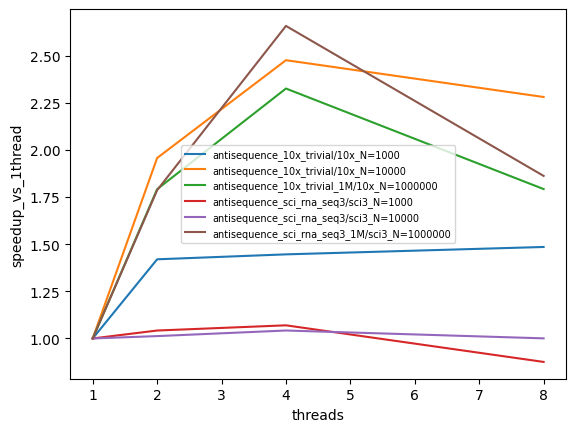

<Figure size 2000x1000 with 0 Axes>

In [3]:
import pandas as pd

# Raw data from the thread experiments (Section 3 / CSV snippet)
# change_percent is the Criterion "change" midpoint vs 1-thread baseline.
records = [
    # antisequence_10x_trivial/10x_N=1000
    {"benchmark": "antisequence_10x_trivial/10x_N=1000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_10x_trivial/10x_N=1000", "threads": 2, "change_percent": -29.561},
    {"benchmark": "antisequence_10x_trivial/10x_N=1000", "threads": 4, "change_percent": -30.837},
    {"benchmark": "antisequence_10x_trivial/10x_N=1000", "threads": 8, "change_percent": -32.664},

    # antisequence_10x_trivial/10x_N=10000
    {"benchmark": "antisequence_10x_trivial/10x_N=10000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_10x_trivial/10x_N=10000", "threads": 2, "change_percent": -48.896},
    {"benchmark": "antisequence_10x_trivial/10x_N=10000", "threads": 4, "change_percent": -59.602},
    {"benchmark": "antisequence_10x_trivial/10x_N=10000", "threads": 8, "change_percent": -56.145},

    # antisequence_sci_rna_seq3/sci3_N=1000
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=1000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=1000", "threads": 2, "change_percent": -4.0355},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=1000", "threads": 4, "change_percent": -6.5096},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=1000", "threads": 8, "change_percent": 14.211},

    # antisequence_sci_rna_seq3/sci3_N=10000
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=10000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=10000", "threads": 2, "change_percent": -1.2307},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=10000", "threads": 4, "change_percent": -4.0435},
    {"benchmark": "antisequence_sci_rna_seq3/sci3_N=10000", "threads": 8, "change_percent": -0.0508},

    # antisequence_10x_trivial_1M/10x_N=1000000
    {"benchmark": "antisequence_10x_trivial_1M/10x_N=1000000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_10x_trivial_1M/10x_N=1000000", "threads": 2, "change_percent": -44.175},
    {"benchmark": "antisequence_10x_trivial_1M/10x_N=1000000", "threads": 4, "change_percent": -56.992},
    {"benchmark": "antisequence_10x_trivial_1M/10x_N=1000000", "threads": 8, "change_percent": -44.198},

    # antisequence_sci_rna_seq3_1M/sci3_N=1000000
    {"benchmark": "antisequence_sci_rna_seq3_1M/sci3_N=1000000", "threads": 1, "change_percent": 0.0},
    {"benchmark": "antisequence_sci_rna_seq3_1M/sci3_N=1000000", "threads": 2, "change_percent": -44.015},
    {"benchmark": "antisequence_sci_rna_seq3_1M/sci3_N=1000000", "threads": 4, "change_percent": -62.365},
    {"benchmark": "antisequence_sci_rna_seq3_1M/sci3_N=1000000", "threads": 8, "change_percent": -46.290},
]

df = pd.DataFrame.from_records(records)

# Compute speedup vs 1-thread baseline
# change_percent is the percent change in time (negative = faster).
# If T_n = time at n threads and T_1 = baseline time:
#   change_percent = 100 * (T_n - T_1) / T_1
#   => T_n / T_1 = 1 + change_percent / 100
#   => speedup = T_1 / T_n = 1 / (1 + change_percent / 100)
df["speedup_vs_1thread"] = 1.0 / (1.0 + df["change_percent"] / 100.0)

# Optional: nice sorting
df = df.sort_values(["benchmark", "threads"]).reset_index(drop=True)
df.round(2)


# Graph this data
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=df, x="threads", y="speedup_vs_1thread", hue="benchmark")
plt.legend(fontsize=7)
plt.figure(figsize=(20, 10))
plt.show()


In [4]:
speedup_table = df.pivot(index="benchmark", columns="threads", values="speedup_vs_1thread")
speedup_table.round(2)

threads,1,2,4,8
benchmark,,,,
antisequence_10x_trivial/10x_N=1000,1.0,1.42,1.45,1.49
antisequence_10x_trivial/10x_N=10000,1.0,1.96,2.48,2.28
antisequence_10x_trivial_1M/10x_N=1000000,1.0,1.79,2.33,1.79
antisequence_sci_rna_seq3/sci3_N=1000,1.0,1.04,1.07,0.88
antisequence_sci_rna_seq3/sci3_N=10000,1.0,1.01,1.04,1.00
antisequence_sci_rna_seq3_1M/sci3_N=1000000,1.0,1.79,2.66,1.86


---
# Chunk size experiments

In [5]:
import re
from pathlib import Path
import pandas as pd

csv_path = Path("benchmark_changes.csv")

rows = []

# Defaults for chunk-size section
current_chunk_size = 512
current_threads = 1

start_chunk_section = False

with csv_path.open() as f:
    for raw in f:
        line = raw.strip()
        if not line:
            continue

        # Wait until we hit the chunk-size section marker
        if not start_chunk_section:
            if line.startswith("## Chunk Size Experiments"):
                start_chunk_section = True
            # Skip everything before that
            continue

        # From here on, we are in the chunk-size subsection only

        # Comment lines carry metadata about chunk_size and threads
        if line.startswith("#"):
            # e.g. "# Running with chunk size 256 (threads 4): ..."
            m_chunk = re.search(r"chunk size\s+(\d+)", line)
            if m_chunk:
                current_chunk_size = int(m_chunk.group(1))

            m_thr = re.search(r"threads\s+(\d+)", line)
            if m_thr:
                current_threads = int(m_thr.group(1))

            continue  # no data in comment lines

        # Data lines: timestamp, benchmark, change_mid_percent
        parts = line.split(",", 2)
        if len(parts) != 3:
            continue

        timestamp, benchmark, change_str = parts
        try:
            change_percent = float(change_str)
        except ValueError:
            continue

        rows.append(
            {
                "timestamp": timestamp,
                "benchmark": benchmark,
                "change_percent": change_percent,
                "chunk_size": current_chunk_size,
                "threads": current_threads,
            }
        )

df_chunks = pd.DataFrame(rows)

# Speedup vs the baseline that Criterion used for this run
df_chunks["speedup"] = 1.0 / (1.0 + df_chunks["change_percent"] / 100.0)

# sort by speedup hightest to lowest
df_chunks = df_chunks.sort_values("speedup", ascending=False)

# remove the timestamp
df_chunks = df_chunks.drop("timestamp", axis=1)

# print(df_chunks)
df_chunks



# # Determine how many of each chunk_size and threads have a speedup < 1.0 (meaning things got worse)
# # count how many of each chunk size and thread have a speedup of < 1.0
# speedup_1 = df_chunks[df_chunks["speedup"] < 1.0]
# speedup_1.groupby(["chunk_size", "threads"]).size()

# # Determine how many of each chunk_size and threads have a speedup > 1.0 (meaning things got better)
# speedup_1 = df_chunks[df_chunks["speedup"] > 1.0]
# speedup_1.groupby(["chunk_size", "threads"]).size()


,benchmark,change_percent,chunk_size,threads,speedup
78,antisequence_sci_rna_seq3_1M/sci3_N=1000000,-66.913,512,8,3.022335
85,antisequence_sci_rna_seq3_1M/sci3_N=1000000,-58.174,1024,2,2.390857
76,antisequence_10x_trivial_1M/10x_N=1000000,-57.510,512,8,2.353495
75,antisequence_sci_rna_seq3/sci3_N=10000,-55.381,512,8,2.241198
73,antisequence_10x_trivial/10x_N=10000,-50.972,512,8,2.039651
...,...,...,...,...,...
49,antisequence_10x_trivial/10x_N=10000,74.976,512,8,0.571507
53,antisequence_sci_rna_seq3_1M/sci3_N=1000000,75.523,512,8,0.569726
47,antisequence_sci_rna_seq3_1M/sci3_N=1000000,85.593,512,4,0.538813
46,antisequence_10x_trivial_1M/10x_N=1000000,108.700,512,4,0.479157


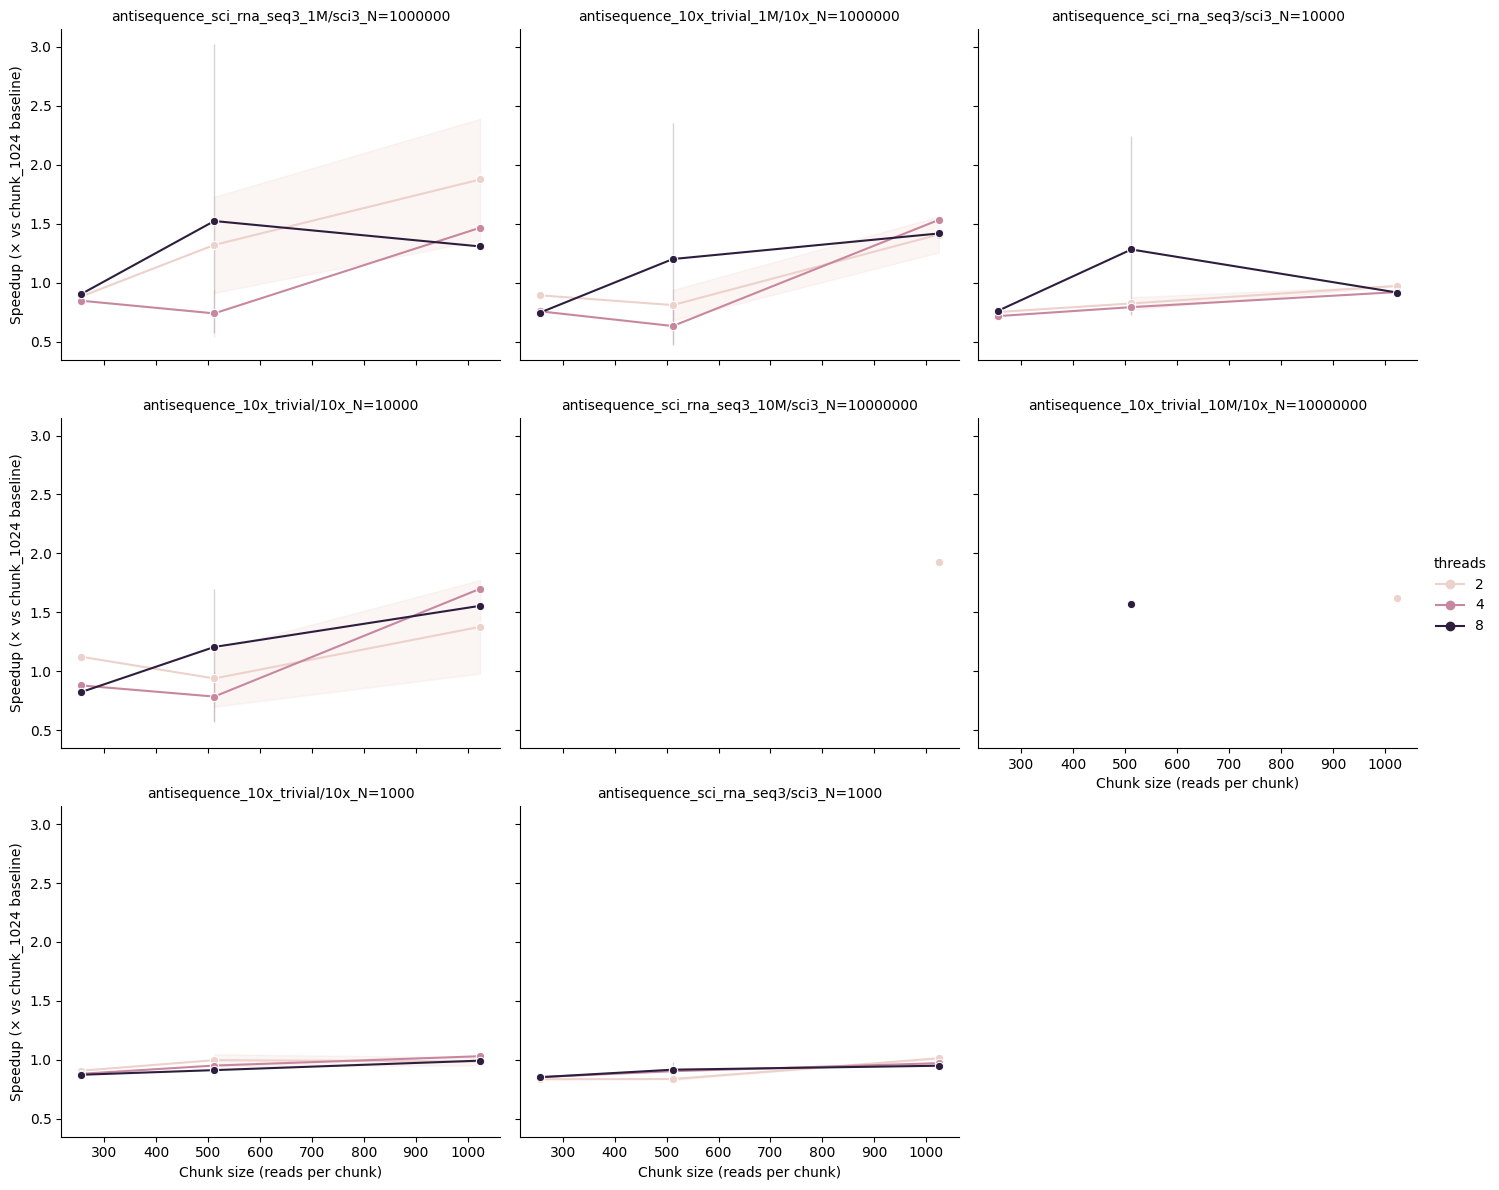

In [6]:
g = sns.relplot(
    data=df_chunks,
    x="chunk_size",
    y="speedup",
    hue="threads",
    col="benchmark",
    col_wrap=3,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
)

g.set_titles("{col_name}")

g.set(
    xlabel="Chunk size (reads per chunk)",
    ylabel="Speedup (× vs chunk_1024 baseline)",
)
plt.show()

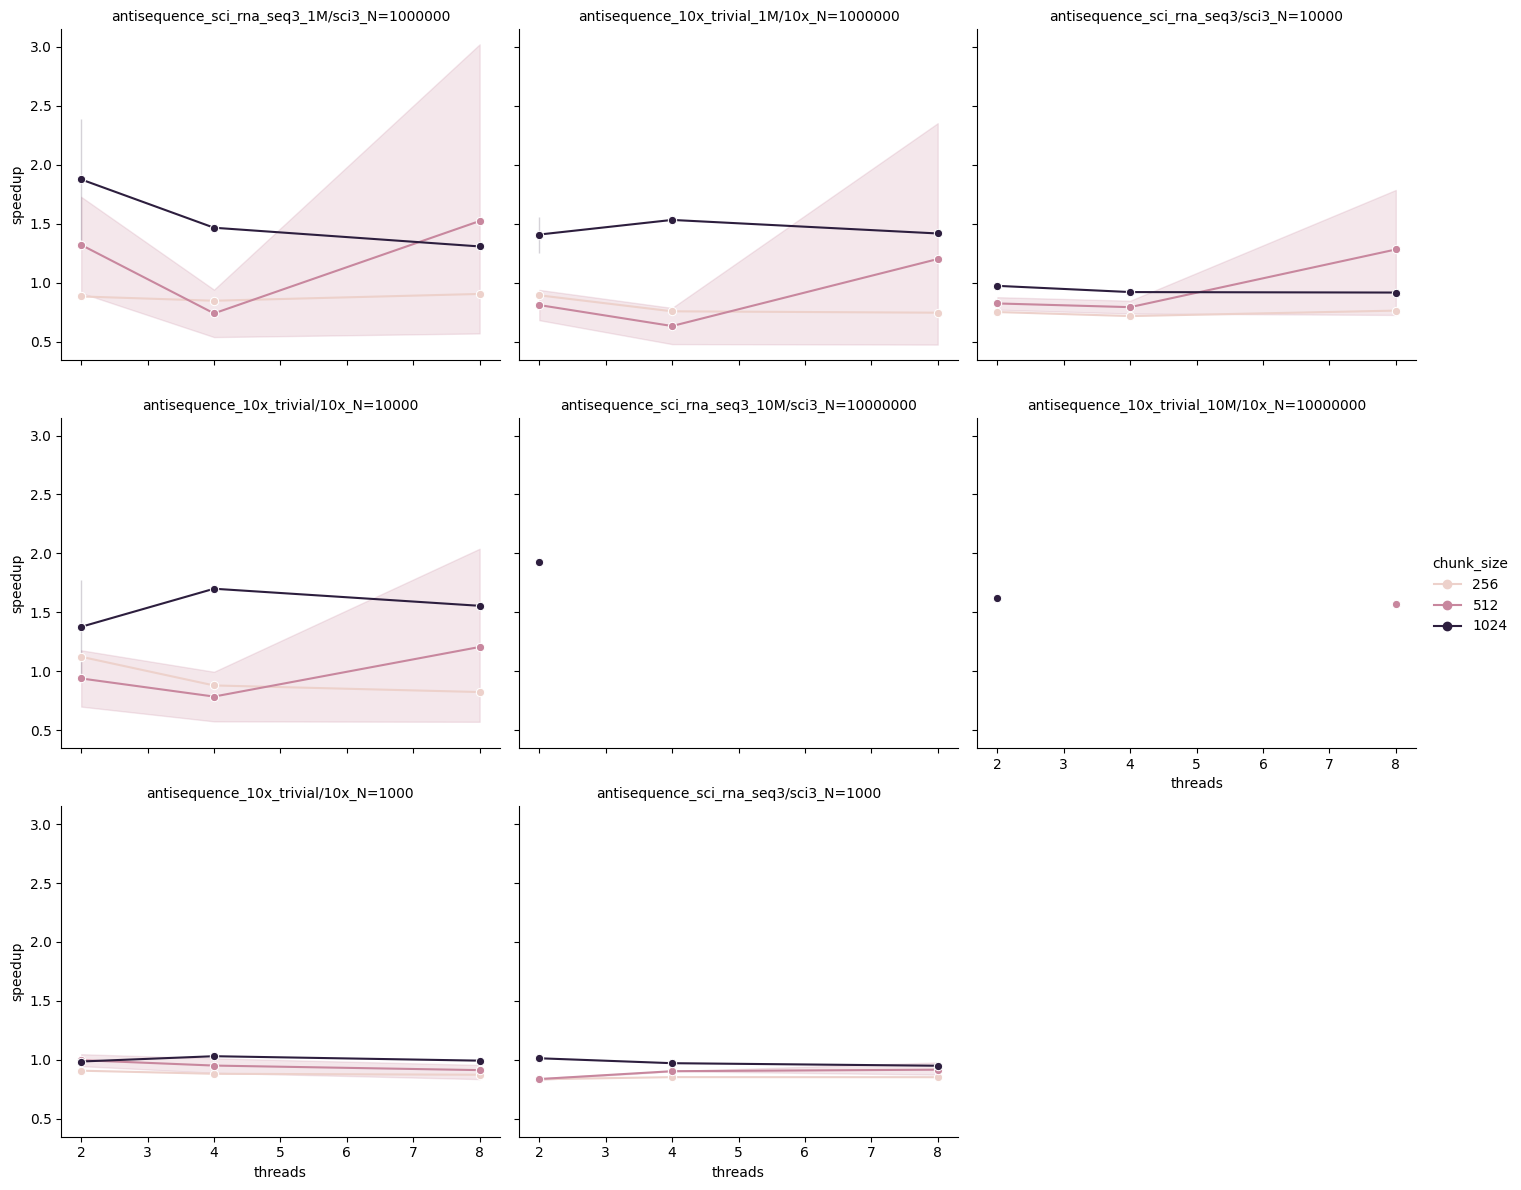

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(
    data=df_chunks,
    x="threads",
    y="speedup",
    hue="chunk_size",
    col="benchmark",
    col_wrap=3,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
)

# Make the title the name of the benchmark
g.set_titles("{col_name}")
plt.show()


---
# Throughput Analysis

In [8]:
# import re
# from pathlib import Path

# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set(style="whitegrid")

# log_path = Path("throughput_4t_c1024.txt")

# # Regexes for the lines we care about
# bench_name_re = re.compile(r"^(antisequence_[^/]+/[^\s]+)\s*$")
# time_re = re.compile(
#     r"time:\s*\[\s*([0-9.]+)\s*(µs|ms|s)\s+([0-9.]+)\s*(µs|ms|s)\s+([0-9.]+)\s*(µs|ms|s)\s*\]"
# )

# rows = []
# current_bench = None

# with log_path.open() as f:
#     for raw in f:
#         line = raw.rstrip()

#         # Capture benchmark name line
#         m_name = bench_name_re.match(line)
#         if m_name:
#             current_bench = m_name.group(1)
#             continue

#         # Capture timing line
#         m_time = time_re.search(line)
#         if m_time and current_bench:
#             # Use median (middle) time
#             mid_val = float(m_time.group(3))
#             mid_unit = m_time.group(4)  # µs/ms/s

#             # Convert to seconds
#             if mid_unit == "s":
#                 t_sec = mid_val
#             elif mid_unit == "ms":
#                 t_sec = mid_val / 1000.0
#             elif mid_unit == "µs":
#                 t_sec = mid_val / 1_000_000.0
#             else:
#                 continue

#             rows.append({"benchmark": current_bench, "time_sec": t_sec})
#             current_bench = None  # reset so we don't accidentally reuse

# df_times = pd.DataFrame(rows)

# # Parse geometry and N from benchmark name
# # Examples:
# #   antisequence_10x_trivial/10x_N=1000
# #   antisequence_10x_trivial_1M/10x_N=1000000
# #   antisequence_10x_trivial_10M/10x_N=10000000
# #   antisequence_sci_rna_seq3/sci3_N=1000
# #   antisequence_sci_rna_seq3_1M/sci3_N=1000000
# #   antisequence_sci_rna_seq3_10M/sci3_N=10000000

# def parse_bench_name(name: str):
#     group, func = name.split("/", 1)
#     # geometry
#     if "10x_trivial" in group:
#         geom = "10x"
#     elif "sci_rna_seq3" in group:
#         geom = "sci3"
#     else:
#         geom = group

#     # read count N from func part "10x_N=1000" / "sci3_N=1000000"
#     m = re.search(r"_N=(\d+)", func)
#     N = int(m.group(1)) if m else None
#     return geom, N

# df_times[["geom", "reads"]] = df_times["benchmark"].apply(
#     lambda s: pd.Series(parse_bench_name(s))
# )

# # Compute throughput: reads per second and in millions of reads/s
# df_times["reads_per_sec"] = df_times["reads"] / df_times["time_sec"]
# df_times["reads_per_sec_M"] = df_times["reads_per_sec"] / 1e6

# df_times = df_times.sort_values(["geom", "reads"]).reset_index(drop=True)
# df_times

In [9]:
# plt.figure(figsize=(6, 4))
# sns.lineplot(
#     data=df_times,
#     x="reads",
#     y="reads_per_sec_M",
#     hue="geom",
#     marker="o",
# )

# plt.xscale("log")
# plt.xlabel("Reads (log scale)")
# plt.ylabel("Throughput (million reads / second)")
# plt.title("Throughput vs read count (4 threads, chunk_size=1024)")
# plt.tight_layout()
# plt.show()

---
# Thread Cache Sweeps from Batch V2

In [10]:
import pandas as pd
import re
from pathlib import Path

# Adjust this if you run the notebook from a different cwd
sweeps_dir = Path("sweeps")

file_re = re.compile(r"bench_c(\d+)_t(\d+)\.csv$")

rows = []

for path in sweeps_dir.glob("bench_c*_t*.csv"):
    m = file_re.search(path.name)
    if not m:
        continue
    chunk = int(m.group(1))
    threads = int(m.group(2))

    df_part = pd.read_csv(path)  # columns: timestamp, benchmark, time_mid_seconds

    for _, r in df_part.iterrows():
        bench = r["benchmark"]
        time_s = float(r["time_mid_seconds"])

        # Extract run size as the last integer in the benchmark string
        m_size = re.search(r"(\d+)(?!.*\d)", bench)
        run_size = int(m_size.group(1)) if m_size else None

        rows.append(
            {
                "chunk": chunk,
                "threads": threads,
                "benchmark": bench,
                "run_size": run_size,
                "time_mid_seconds": time_s,
            }
        )

df = pd.DataFrame(rows)
df

,chunk,threads,benchmark,run_size,time_mid_seconds
0,2048,4,antisequence_10x_trivial/10x_N=1000,1000,0.001000
1,2048,4,antisequence_10x_trivial/10x_N=10000,10000,0.008919
2,2048,4,antisequence_sci_rna_seq3/sci3_N=1000,1000,0.001301
3,2048,4,antisequence_sci_rna_seq3/sci3_N=10000,10000,0.010177
4,2048,4,antisequence_10x_trivial_1M/10x_N=1000000,1000000,0.467180
...,...,...,...,...,...
123,2048,8,antisequence_sci_rna_seq3/sci3_N=10000,10000,0.012558
124,2048,8,antisequence_10x_trivial_1M/10x_N=1000000,1000000,0.634230
125,2048,8,antisequence_10x_trivial_10M/10x_N=10000000,10000000,6.164600
126,2048,8,antisequence_sci_rna_seq3_1M/sci3_N=1000000,1000000,0.700450


In [11]:
# Maximum run size across all benchmarks (e.g. 10M)
max_run = df["run_size"].max()

df_max = df[df["run_size"] == max_run]

# Row with minimal median time among those
best = df_max.loc[df_max["time_mid_seconds"].idxmin()]

print("Max run size:", max_run)
print("Best median time (s):", best["time_mid_seconds"])
print("Best chunk size:", best["chunk"])
print("Best threads:", best["threads"])
print("Benchmark:", best["benchmark"])

# (Optional) view all configs for that run size, sorted by time
df_max.sort_values("time_mid_seconds").head(20)

Max run size: 10000000
Best median time (s): 1.995
Best chunk size: 512
Best threads: 4
Benchmark: antisequence_sci_rna_seq3_10M/sci3_N=10000000


,chunk,threads,benchmark,run_size,time_mid_seconds
79,512,4,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,1.9950
77,512,4,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.1119
119,256,4,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,2.1871
55,256,8,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,2.2007
29,1024,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.2425
37,512,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.2459
85,256,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.2585
53,256,8,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.4541
117,256,4,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.5634
109,512,8,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.8384


In [12]:
import matplotlib.pyplot as plt

def plot_times_by_chunk_thread(
    df,
    run_size=None,
    bench_contains=None,
    agg="mean",
    title=None,
):
    """
    Plot median/aggregated times vs threads, one line per chunk size.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: chunk, threads, benchmark, run_size, time_mid_seconds.
    run_size : int or None
        If set, filter to this run_size (e.g. max N). If None, use all.
    bench_contains : str or None
        If set, keep only rows where 'bench_contains' is a substring of benchmark.
    agg : str
        Aggregation over benchmarks: 'mean', 'min', 'max', etc.
    title : str or None
        Optional plot title.
    """
    d = df.copy()

    if run_size is not None:
        d = d[d["run_size"] == run_size]

    if bench_contains is not None:
        d = d[d["benchmark"].str.contains(bench_contains)]

    if d.empty:
        print("No data after filtering; nothing to plot.")
        return

    # Aggregate over benchmarks for each (threads, chunk)
    grouped = (
        d.groupby(["threads", "chunk"], as_index=False)["time_mid_seconds"]
        .agg(agg)
        .rename(columns={"time_mid_seconds": "time_s"})
    )

    # Pivot: rows = threads, cols = chunk, values = time_s
    pivot = grouped.pivot(index="threads", columns="chunk", values="time_s")
    pivot = pivot.sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))

    for chunk, col in pivot.items():
        ax.plot(
            pivot.index,
            col.values,
            marker="o",
            label=f"chunk={chunk}",
        )

    ax.set_xlabel("Threads")
    ax.set_ylabel(f"{agg} median time (s)")
    if title is None:
        if run_size is not None:
            title = f"{agg} median time vs threads (run_size={run_size})"
        else:
            title = f"{agg} median time vs threads (all run sizes)"
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Chunk size")
    plt.tight_layout()
    plt.show()

## Plot Best settings for max run size across all benches:

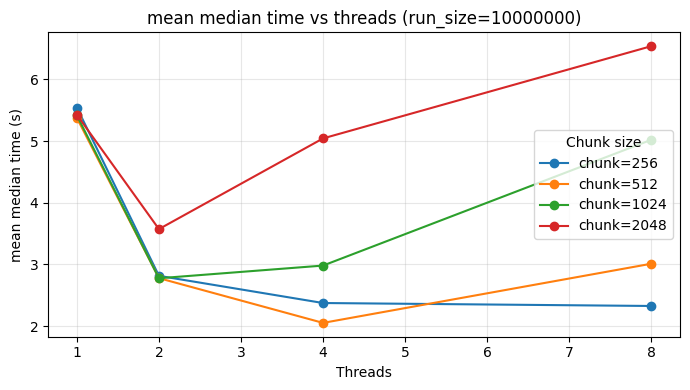

In [13]:
max_run = df["run_size"].max()
plot_times_by_chunk_thread(df, run_size=max_run)

## Only 10x benchmarks:

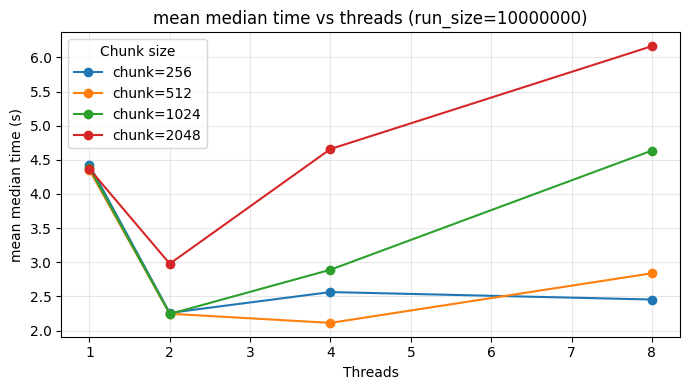

In [14]:
plot_times_by_chunk_thread(df, run_size=max_run, bench_contains="10x_trivial")

## Using minimum over benchmarks (instead of mean):

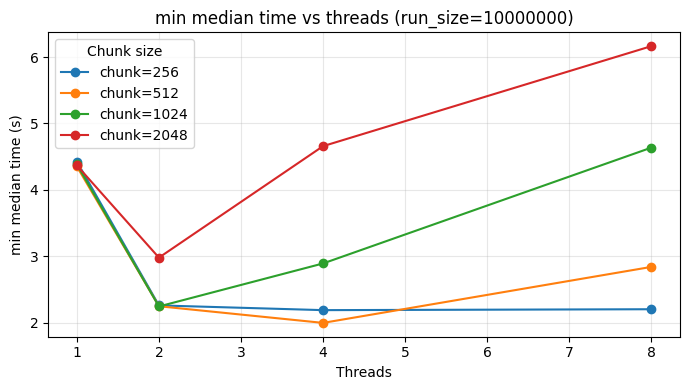

In [15]:
plot_times_by_chunk_thread(df, run_size=max_run, agg="min")

---
# Plotly plotting

In [16]:
import plotly.express as px
import plotly.graph_objects as go

def make_agg_df(df, run_size=None, bench_contains=None, agg="mean"):
    """
    Aggregate median times over benchmarks for each (threads, chunk).

    df: DataFrame with columns chunk, threads, benchmark, run_size, time_mid_seconds
    run_size: if None, use max run_size
    bench_contains: optional substring to filter benchmarks
    agg: 'mean', 'min', 'max', etc.
    """
    d = df.copy()

    if run_size is None:
        run_size = d["run_size"].max()

    d = d[d["run_size"] == run_size]

    if bench_contains is not None:
        d = d[d["benchmark"].str.contains(bench_contains)]

    if d.empty:
        raise ValueError("No data after filtering.")

    g = (
        d.groupby(["threads", "chunk"], as_index=False)["time_mid_seconds"]
         .agg(agg)
         .rename(columns={"time_mid_seconds": "time_s"})
    )
    return g, run_size

In [17]:
agg_df, rs = make_agg_df(df, run_size=None, bench_contains=None, agg="mean")

fig_line = px.line(
    agg_df,
    x="threads",
    y="time_s",
    color="chunk",
    markers=True,
    title=f"Aggregated { 'mean' } median time vs threads (run_size={rs})",
    hover_data=["chunk", "threads", "time_s"],
)
fig_line.update_layout(
    xaxis_title="Threads",
    yaxis_title="Median time (s)",
)
fig_line.show()

In [18]:
import plotly.express as px
import pandas as pd

# If you have the make_agg_df helper already, you can reuse it.
# Otherwise, here's an inline version focused on aggregation:

def make_agg_df_all_tests(df, run_size=None, agg="mean"):
    """
    Aggregate time_mid_seconds across all benchmarks
    for each (threads, chunk), at a given run_size.
    """
    d = df.copy()

    if run_size is None:
        run_size = d["run_size"].max()

    d = d[d["run_size"] == run_size]

    if d.empty:
        raise ValueError("No data for run_size={run_size}")

    g = (
        d.groupby(["threads", "chunk"], as_index=False)["time_mid_seconds"]
         .agg(agg)
         .rename(columns={"time_mid_seconds": "time_s"})
    )
    return g, run_size

# Build aggregated table over all tests
agg_df_all, rs = make_agg_df_all_tests(df, run_size=1000000, agg="mean")

# Interactive heatmap``
fig = px.density_heatmap(
    agg_df_all,
    x="threads",
    y="chunk",
    z="time_s",
    color_continuous_scale="Viridis",
    labels={
        "threads": "Threads",
        "chunk": "Chunk size",
        "time_s": "Mean median time (s)",
    },
    title=f"Aggregated mean median time across all benchmarks (run_size={rs})",
)

# Treat threads/chunk as categories so they show as discrete ticks
fig.update_xaxes(type="category")
fig.update_yaxes(type="category")

fig.show()

In [19]:
agg_df_all, rs = make_agg_df_all_tests(df, run_size=10000000, agg="mean")

# Interactive heatmap``
fig = px.density_heatmap(
    agg_df_all,
    x="threads",
    y="chunk",
    z="time_s",
    color_continuous_scale="Viridis",
    labels={
        "threads": "Threads",
        "chunk": "Chunk size",
        "time_s": "Mean median time (s)",
    },
    title=f"Aggregated mean median time across all benchmarks (run_size={rs})",
)

# Treat threads/chunk as categories so they show as discrete ticks
fig.update_xaxes(type="category")
fig.update_yaxes(type="category")

fig.show()

In [20]:
import numpy as np
import plotly.graph_objects as go

# Unique values
run_sizes = sorted(df["run_size"].dropna().unique())
chunks = sorted(df["chunk"].unique())
threads = sorted(df["threads"].unique())

fig = go.Figure()
buttons = []

for i, rs in enumerate(run_sizes):
    # Aggregate over benchmarks for this run_size: mean median time per (chunk, threads)
    d = df[df["run_size"] == rs]
    g = (
        d.groupby(["chunk", "threads"])["time_mid_seconds"]
         .mean()
         .reset_index()
    )

    # Pivot to matrix: rows = chunk, cols = threads
    pivot = (
        g.pivot(index="chunk", columns="threads", values="time_mid_seconds")
         .reindex(index=chunks, columns=threads)
    )
    z = pivot.values

    visible = (i == 0)
    fig.add_trace(
        go.Heatmap(
            z=z,
            x=threads,
            y=chunks,
            colorscale="Viridis",
            colorbar_title="Mean median time (s)",
            visible=visible,
            name=f"N={rs}",
            hovertemplate=(
                "threads=%{x}<br>"
                "chunk=%{y}<br>"
                "time=%{z:.3f} s"
                f"<br>run_size={rs}<extra></extra>"
            ),
        )
    )

    buttons.append(
        dict(
            label=f"N={rs}",
            method="update",
            args=[
                {"visible": [j == i for j in range(len(run_sizes))]},
                {"title": f"Aggregated mean median time (run_size={rs})"},
            ],
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            x=1.05,
            y=1.2,
            showactive=True,
            buttons=buttons,
        )
    ],
    xaxis_title="Threads",
    yaxis_title="Chunk size",
    title=f"Aggregated mean median time (run_size={run_sizes[0]})",
)

fig.show()

In [21]:
import numpy as np
import plotly.graph_objects as go

# Unique values, sorted
run_sizes = sorted(df["run_size"].dropna().unique())
chunks = sorted(df["chunk"].unique())
threads = sorted(df["threads"].unique())

fig = go.Figure()
buttons = []

num_chunks = len(chunks)

for i, rs in enumerate(run_sizes):
    # Aggregate over benchmarks for this run_size: mean median time per (chunk, threads)
    d = df[df["run_size"] == rs]
    g = (
        d.groupby(["chunk", "threads"])["time_mid_seconds"]
         .mean()
         .reset_index()
    )

    # For this run_size, add one trace per chunk (threads on x, time on y)
    for k, c in enumerate(chunks):
        sub = g[g["chunk"] == c].sort_values("threads")
        visible = (i == 0)  # Only first run_size visible initially
        fig.add_trace(
            go.Scatter(
                x=sub["threads"],
                y=sub["time_mid_seconds"],
                mode="lines+markers",
                name=f"chunk={c}",
                legendgroup=f"chunk_{c}",
                showlegend=(i == 0),   # only show legend once
                visible=visible,
                hovertemplate=(
                    "threads=%{x}<br>"
                    "time=%{y:.3f} s<br>"
                    f"chunk={c}, run_size={rs}<extra></extra>"
                ),
            )
        )

    # Visibility mask for this run_size (block of traces)
    visible_mask = []
    total_traces = len(run_sizes) * num_chunks
    for idx in range(total_traces):
        # traces [i * num_chunks : (i+1) * num_chunks] belong to run_size rs
        visible_mask.append(i * num_chunks <= idx < (i + 1) * num_chunks)

    buttons.append(
        dict(
            label=f"N={rs}",
            method="update",
            args=[
                {"visible": visible_mask},
                {"title": f"Aggregated mean median time vs threads (run_size={rs})"},
            ],
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            x=1.05,
            y=1.2,
            showactive=True,
            buttons=buttons,
        )
    ],
    xaxis_title="Threads",
    yaxis_title="Mean median time (s)",
    title=f"Aggregated mean median time vs threads (run_size={run_sizes[0]})",
)
fig.show()

## Throughput analysis with the new batch optimization v2 data

In [22]:
import numpy as np

# reads per second
df["throughput_rps"] = df["run_size"] / df["time_mid_seconds"]

# (optional) log throughput if you want easier visual scaling
df["log_throughput_rps"] = np.log10(df["throughput_rps"]) 

df.sort_values("log_throughput_rps", ascending=False).head(25)

,chunk,threads,benchmark,run_size,time_mid_seconds,throughput_rps,log_throughput_rps
79,512,4,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,1.995000,5.012531e+06,6.700057
78,512,4,antisequence_sci_rna_seq3_1M/sci3_N=1000000,1000000,0.208980,4.785147e+06,6.679895
77,512,4,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.111900,4.735073e+06,6.675327
119,256,4,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,2.187100,4.572265e+06,6.660131
76,512,4,antisequence_10x_trivial_1M/10x_N=1000000,1000000,0.219490,4.556016e+06,6.658585
55,256,8,antisequence_sci_rna_seq3_10M/sci3_N=10000000,10000000,2.200700,4.544009e+06,6.657439
54,256,8,antisequence_sci_rna_seq3_1M/sci3_N=1000000,1000000,0.220460,4.535970e+06,6.656670
29,1024,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.242500,4.459309e+06,6.649268
37,512,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.245900,4.452558e+06,6.648610
85,256,2,antisequence_10x_trivial_10M/10x_N=10000000,10000000,2.258500,4.427718e+06,6.646180


In [23]:
import plotly.graph_objects as go

run_sizes = sorted(df["run_size"].dropna().unique())
chunks = sorted(df["chunk"].unique())
threads = sorted(df["threads"].unique())

fig = go.Figure()
buttons = []

num_chunks = len(chunks)

for i, rs in enumerate(run_sizes):
    # Aggregate throughput for this run_size: mean over benchmarks
    d = df[df["run_size"] == rs]
    g = (
        d.groupby(["chunk", "threads"])["throughput_rps"]
         .mean()
         .reset_index()
    )

    for k, c in enumerate(chunks):
        sub = g[g["chunk"] == c].sort_values("threads")
        visible = (i == 0)
        fig.add_trace(
            go.Scatter(
                x=sub["threads"],
                y=sub["throughput_rps"],
                mode="lines+markers",
                name=f"chunk={c}",
                legendgroup=f"chunk_{c}",
                showlegend=(i == 0),
                visible=visible,
                hovertemplate=(
                    "threads=%{x}<br>"
                    "throughput=%{y:.2e} reads/s<br>"
                    f"chunk={c}, run_size={rs}<extra></extra>"
                ),
            )
        )

    visible_mask = []
    total_traces = len(run_sizes) * num_chunks
    for idx in range(total_traces):
        visible_mask.append(i * num_chunks <= idx < (i + 1) * num_chunks)

    buttons.append(
        dict(
            label=f"N={rs}",
            method="update",
            args=[
                {"visible": visible_mask},
                {"title": f"Mean throughput vs threads (run_size={rs})"},
            ],
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            x=1.05,
            y=1.2,
            showactive=True,
            buttons=buttons,
        )
    ],
    xaxis_title="Threads",
    yaxis_title="Mean throughput (reads/s)",
    title=f"Mean throughput vs threads (run_size={run_sizes[0]})",
)
fig.show()

In [24]:
run_sizes = sorted(df["run_size"].dropna().unique())
chunks = sorted(df["chunk"].unique())
threads = sorted(df["threads"].unique())

fig = go.Figure()
buttons = []

for i, rs in enumerate(run_sizes):
    d = df[df["run_size"] == rs]
    g = (
        d.groupby(["chunk", "threads"])["throughput_rps"]
         .mean()
         .reset_index()
    )

    pivot = (
        g.pivot(index="chunk", columns="threads", values="throughput_rps")
         .reindex(index=chunks, columns=threads)
    )
    z = pivot.values

    visible = (i == 0)
    fig.add_trace(
        go.Heatmap(
            z=z,
            x=threads,
            y=chunks,
            colorscale="Viridis",
            colorbar_title="Mean throughput\n(reads/s)",
            visible=visible,
            name=f"N={rs}",
            hovertemplate=(
                "threads=%{x}<br>"
                "chunk=%{y}<br>"
                "throughput=%{z:.2e} reads/s"
                f"<br>run_size={rs}<extra></extra>"
            ),
        )
    )

    visible_mask = []
    total_traces = len(run_sizes)
    for idx in range(total_traces):
        visible_mask.append(idx == i)

    buttons.append(
        dict(
            label=f"N={rs}",
            method="update",
            args=[
                {"visible": [j == i for j in range(total_traces)]},
                {"title": f"Mean throughput heatmap (run_size={rs})"},
            ],
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            x=1.05,
            y=1.2,
            showactive=True,
            buttons=buttons,
        )
    ],
    xaxis_title="Threads",
    yaxis_title="Chunk size",
    title=f"Mean throughput heatmap (run_size={run_sizes[0]})",
)
fig.show()

,tool,protocol,run_size,threads,time_mid_seconds,throughput_rps
0,seqproc,10x,1000000,4,0.552418,1.810225e+06
6,splitcode,10x,1000000,4,0.608546,1.643261e+06
1,seqproc,10x,10000000,4,2.875290,3.477911e+06
7,splitcode,10x,10000000,4,5.626276,1.777374e+06
2,seqproc,sci3,1000000,4,0.536241,1.864834e+06
8,splitcode,sci3,1000000,4,0.907172,1.102327e+06
3,seqproc,sci3,10000000,4,2.634370,3.795974e+06
9,splitcode,sci3,10000000,4,8.630592,1.158669e+06
4,seqproc,sci3_tolerant,1000000,4,0.555125,1.801395e+06
10,splitcode,sci3_tolerant,1000000,4,0.919589,1.087442e+06


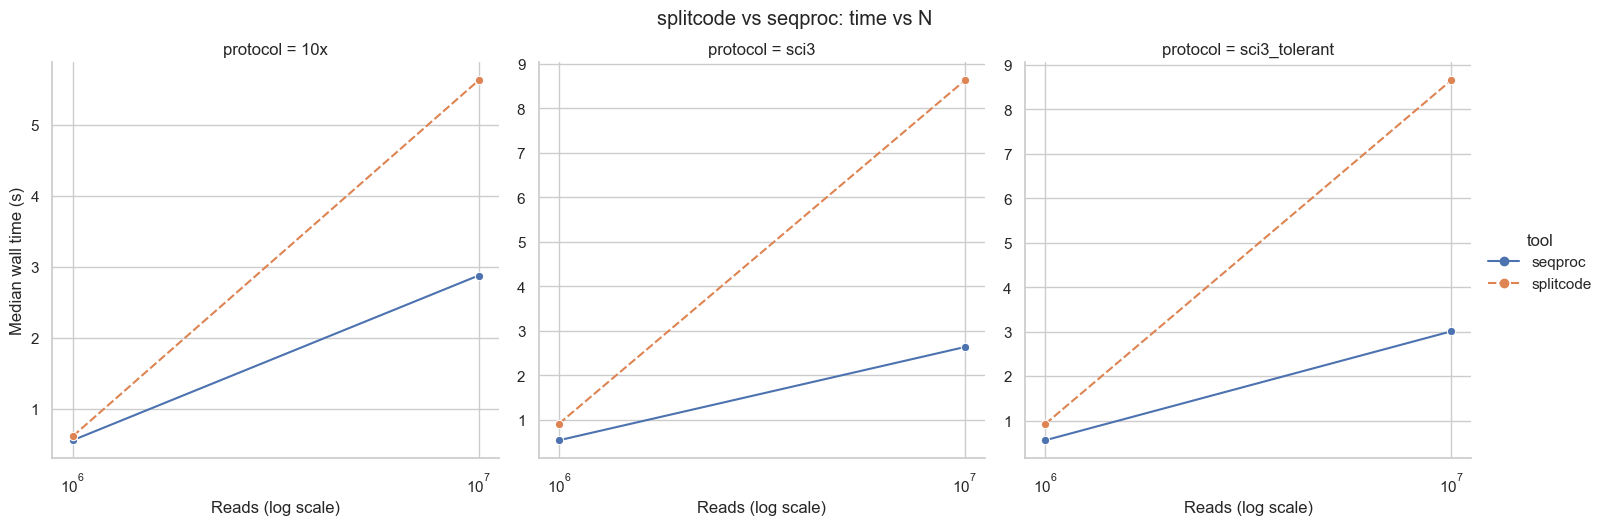

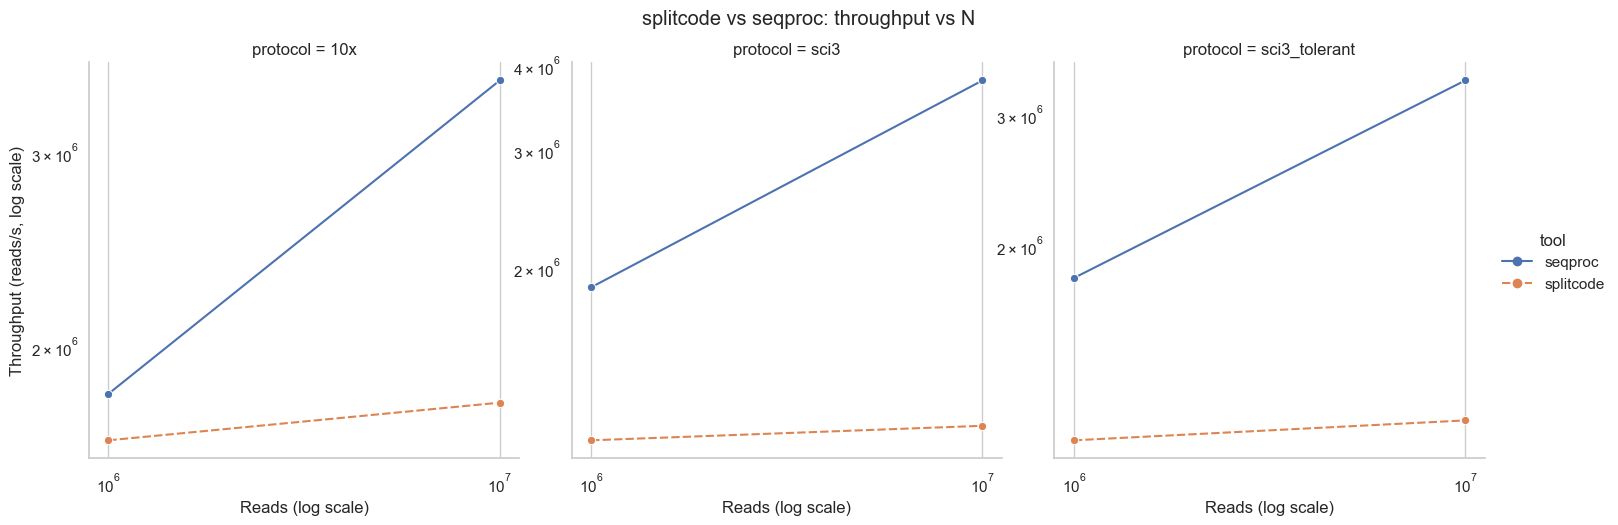

seqproc  splitcode  seqproc_over_splitcode
protocol      run_size threads                                             
10x           1000000  4        0.552418   0.608546                0.907766
              10000000 4        2.875290   5.626276                0.511047
sci3          1000000  4        0.536241   0.907172                0.591112
              10000000 4        2.634370   8.630592                0.305236
sci3_tolerant 1000000  4        0.555125   0.919589                0.603667
              10000000 4        3.003353   8.644129                0.347444

In [1]:
# --- splitcode vs seqproc comparison from split_vs_seqproc_times.csv ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load combined benchmark CSV produced by run_splitcode_seqproc_benchmarks.py
csv_path = "split_vs_seqproc_times_all.csv"
df_tools = pd.read_csv(csv_path)

# Aggregate in case there are multiple rows per (tool, protocol, N, threads)
df_tools_agg = (
    df_tools.groupby(["tool", "protocol", "run_size", "threads"], as_index=False)["time_mid_seconds"]
    .mean()
)

# Throughput (reads per second)
df_tools_agg["throughput_rps"] = df_tools_agg["run_size"] / df_tools_agg["time_mid_seconds"]

display(df_tools_agg.sort_values(["protocol", "run_size", "tool"]))

sns.set(style="whitegrid")

# Time vs N (per protocol, comparing tools)
g_time = sns.relplot(
    data=df_tools_agg,
    x="run_size",
    y="time_mid_seconds",
    hue="tool",
    style="tool",
    col="protocol",
    kind="line",
    marker="o",
    facet_kws={"sharex": False, "sharey": False},
)
g_time.set(xscale="log")
g_time.set_axis_labels("Reads (log scale)", "Median wall time (s)")
g_time.fig.suptitle("splitcode vs seqproc: time vs N", y=1.03)
plt.show()

# Throughput vs N (per protocol, comparing tools)
g_thr = sns.relplot(
    data=df_tools_agg,
    x="run_size",
    y="throughput_rps",
    hue="tool",
    style="tool",
    col="protocol",
    kind="line",
    marker="o",
    facet_kws={"sharex": False, "sharey": False},
)
g_thr.set(xscale="log", yscale="log")
g_thr.set_axis_labels("Reads (log scale)", "Throughput (reads/s, log scale)")
g_thr.fig.suptitle("splitcode vs seqproc: throughput vs N", y=1.03)
plt.show()

# Speedup table: seqproc_time / splitcode_time (>1 => splitcode faster)
speed = (
    df_tools_agg.pivot_table(
        index=["protocol", "run_size", "threads"],
        columns="tool",
        values="time_mid_seconds",
    )
    .rename_axis(columns=None)
)
if {"seqproc", "splitcode"}.issubset(speed.columns):
    speed["seqproc_over_splitcode"] = speed["seqproc"] / speed["splitcode"]

display(speed.sort_index())


In [28]:
# --- Summary helper: compact splitcode vs seqproc speedup table ---
import pandas as pd

csv_path = "split_vs_seqproc_times_all.csv"
_df_tools = pd.read_csv(csv_path)

# Aggregate duplicate rows, if any
_df_agg = (
    _df_tools.groupby(["tool", "protocol", "run_size", "threads"], as_index=False)["time_mid_seconds"]
    .mean()
)

# Pivot to have columns for each tool
_pivot = (
    _df_agg.pivot_table(
        index=["protocol", "run_size", "threads"],
        columns="tool",
        values="time_mid_seconds",
    )
    .rename_axis(columns=None)
)

if {"seqproc", "splitcode"}.issubset(_pivot.columns):
    _pivot["seqproc_over_splitcode"] = _pivot["seqproc"] / _pivot["splitcode"]
    _pivot["splitcode_over_seqproc"] = _pivot["splitcode"] / _pivot["seqproc"]

summary = _pivot.reset_index().sort_values(["protocol", "run_size", "threads"])  # small tidy table

display(summary)

# Textual summary per (protocol, run_size, threads)
for _, row in summary.iterrows():
    prot = row["protocol"]
    N = int(row["run_size"])
    thr = int(row["threads"])
    s_over_sc = row.get("seqproc_over_splitcode")
    sc_over_s = row.get("splitcode_over_seqproc")

    if pd.isna(s_over_sc) or pd.isna(sc_over_s):
        continue

    if s_over_sc > 1:
        # seqproc slower, splitcode faster
        print(
            f"protocol={prot}, N={N:,}, threads={thr}: "
            f"splitcode is {s_over_sc:.2f}x faster than seqproc."
        )
    elif sc_over_s > 1:
        # seqproc faster
        print(
            f"protocol={prot}, N={N:,}, threads={thr}: "
            f"seqproc is {sc_over_s:.2f}x faster than splitcode."
        )
    else:
        print(
            f"protocol={prot}, N={N:,}, threads={thr}: "
            f"splitcode and seqproc are ~tied (ratio≈1)."
        )


,protocol,run_size,threads,seqproc,splitcode,seqproc_over_splitcode,splitcode_over_seqproc
0,10x,1000000,4,0.552418,0.608546,0.907766,1.101605
1,10x,10000000,4,2.875290,5.626276,0.511047,1.956769
2,sci3,1000000,4,0.536241,0.907172,0.591112,1.691726
3,sci3,10000000,4,2.634370,8.630592,0.305236,3.276150
4,sci3_tolerant,1000000,4,0.555125,0.919589,0.603667,1.656543
5,sci3_tolerant,10000000,4,3.003353,8.644129,0.347444,2.878159


protocol=10x, N=1,000,000, threads=4: seqproc is 1.10x faster than splitcode.
protocol=10x, N=10,000,000, threads=4: seqproc is 1.96x faster than splitcode.
protocol=sci3, N=1,000,000, threads=4: seqproc is 1.69x faster than splitcode.
protocol=sci3, N=10,000,000, threads=4: seqproc is 3.28x faster than splitcode.
protocol=sci3_tolerant, N=1,000,000, threads=4: seqproc is 1.66x faster than splitcode.
protocol=sci3_tolerant, N=10,000,000, threads=4: seqproc is 2.88x faster than splitcode.


In [29]:
# --- Validation: seqproc vs splitcode vs ground truth for N=1_000_000 ---
from pathlib import Path
from itertools import zip_longest
import math

base = Path("data/bench")


def iter_fastq_seqs(path: Path):
    """Stream sequences from a FASTQ file without loading everything into RAM."""
    with path.open() as f:
        while True:
            h = f.readline()
            if not h:
                return
            seq = f.readline().rstrip("\n")
            plus = f.readline()
            qual = f.readline()
            if not qual:
                return
            yield seq


def validate_protocol_n(protocol: str, n: int) -> None:
    in_r1 = base / f"{protocol}_N{n}_R1.fastq"
    in_r2 = base / f"{protocol}_N{n}_R2.fastq"
    sp_r1 = base / f"seqproc_{protocol}_N{n}_R1.fastq"
    sp_r2 = base / f"seqproc_{protocol}_N{n}_R2.fastq"
    sc_r1 = base / f"splitcode_{protocol}_N{n}_R1.fastq"
    sc_r2 = base / f"splitcode_{protocol}_N{n}_R2.fastq"

    for p in [in_r1, in_r2, sp_r1, sp_r2, sc_r1, sc_r2]:
        assert p.exists(), f"Missing expected FASTQ file: {p}"

    print(f"\n=== Validating protocol={protocol}, N={n:,} ===")

    # R1: compare input vs seqproc vs splitcode
    r1_count = 0
    for i, (s_in, s_sp, s_sc) in enumerate(
        zip_longest(
            iter_fastq_seqs(in_r1),
            iter_fastq_seqs(sp_r1),
            iter_fastq_seqs(sc_r1),
        )
    ):
        assert s_in is not None and s_sp is not None and s_sc is not None, "R1: mismatch in read counts"
        # Ground truth: seqproc and splitcode should match input exactly
        assert s_in == s_sp == s_sc, f"R1: sequence mismatch at read {i} for {protocol}, N={n}"

        if protocol == "10x":
            assert len(s_in) == 26, f"R1: expected length 26 for 10x, got {len(s_in)} at read {i}"
        else:  # sci3
            expected_len = 33 if i % 2 == 0 else 34
            assert len(s_in) == expected_len, (
                f"R1: expected length {expected_len} for sci3, got {len(s_in)} at read {i}"
            )
            offset = 9 if i % 2 == 0 else 10
            assert s_in[offset:offset+6] == "CAGAGC", (
                f"R1: missing anchor CAGAGC at expected offset {offset} (read {i})"
            )
        r1_count += 1

    # R2: input vs seqproc vs splitcode, and length checks
    r2_count = 0
    for i, (s_in, s_sp, s_sc) in enumerate(
        zip_longest(
            iter_fastq_seqs(in_r2),
            iter_fastq_seqs(sp_r2),
            iter_fastq_seqs(sc_r2),
        )
    ):
        assert s_in is not None and s_sp is not None and s_sc is not None, "R2: mismatch in read counts"
        assert s_in == s_sp == s_sc, f"R2: sequence mismatch at read {i} for {protocol}, N={n}"

        expected_len_r2 = 60 if protocol == "10x" else 80
        assert len(s_in) == expected_len_r2, (
            f"R2: expected length {expected_len_r2} for {protocol}, got {len(s_in)} at read {i}"
        )
        r2_count += 1

    print(f"R1 reads validated: {r1_count:,}")
    print(f"R2 reads validated: {r2_count:,}")
    assert r1_count == n and r2_count == n, "Read count mismatch vs N"
    print("Status: OK (seqproc == splitcode == ground truth for both R1 and R2)")


for prot in ["10x", "sci3"]:
    validate_protocol_n(prot, 1_000_000)



=== Validating protocol=10x, N=1,000,000 ===
R1 reads validated: 1,000,000
R2 reads validated: 1,000,000
Status: OK (seqproc == splitcode == ground truth for both R1 and R2)

=== Validating protocol=sci3, N=1,000,000 ===
R1 reads validated: 1,000,000
R2 reads validated: 1,000,000
Status: OK (seqproc == splitcode == ground truth for both R1 and R2)


In [30]:
# --- Concrete per-base throughput check for 10M runs ---
import pandas as pd

# Reuse df_tools_agg from the splitcode vs seqproc comparison cell
_df = df_tools_agg.copy()

# Exact total bases, using known read lengths per protocol and N
# 10x: R1=26, R2=60 => 86 bases/read pair
# sci3: R1 alternates 33/34 with anchor at offset 9/10, R2=80
#       For a given N: even-index reads have 33, odd-index 34.
def total_bases(protocol: str, n: int) -> int:
    if protocol == "10x":
        return n * (26 + 60)
    elif protocol == "sci3":
        n_even = n // 2
        n_odd = n - n_even
        total_r1 = n_even * 33 + n_odd * 34
        total_r2 = n * 80
        return total_r1 + total_r2
    else:
        raise ValueError(f"Unknown protocol: {protocol}")

_df["total_bases"] = _df.apply(
    lambda r: total_bases(r["protocol"], int(r["run_size"])), axis=1
)
_df["bases_per_sec"] = _df["total_bases"] / _df["time_mid_seconds"]

# Focus on N=10M rows to match the textual reasoning
mask_10m = _df["run_size"] == 10_000_000
throughput_10m = _df[mask_10m].sort_values(["protocol", "tool"])

display(throughput_10m[["tool", "protocol", "run_size", "threads", "time_mid_seconds", "total_bases", "bases_per_sec"]])

# For easier reading, print a compact summary
for _, row in throughput_10m.iterrows():
    tool = row["tool"]
    prot = row["protocol"]
    n = int(row["run_size"])
    t = row["time_mid_seconds"]
    bases = int(row["total_bases"])
    bps = row["bases_per_sec"]
    print(
        f"tool={tool:8s} protocol={prot:4s} N={n:,}: "
        f"{bases:.3e} bases / {t:.3f} s = {bps:.3e} bases/s"
    )


ValueError: Unknown protocol: sci3_tolerant

In [ ]:
# --- Sampled validation for N=10M (every 100th read up to 100k samples) ---
from itertools import zip_longest
from pathlib import Path

base = Path("data/bench")  # reuse same base dir


def validate_protocol_n_sampled(protocol: str, n: int, sample_every: int = 100, max_samples: int = 100_000) -> None:
    in_r1 = base / f"{protocol}_N{n}_R1.fastq"
    in_r2 = base / f"{protocol}_N{n}_R2.fastq"
    sp_r1 = base / f"seqproc_{protocol}_N{n}_R1.fastq"
    sp_r2 = base / f"seqproc_{protocol}_N{n}_R2.fastq"
    sc_r1 = base / f"splitcode_{protocol}_N{n}_R1.fastq"
    sc_r2 = base / f"splitcode_{protocol}_N{n}_R2.fastq"

    for p in [in_r1, in_r2, sp_r1, sp_r2, sc_r1, sc_r2]:
        assert p.exists(), f"Missing expected FASTQ file: {p}"

    print(f"\n=== Sampled validation protocol={protocol}, N={n:,} ===")
    print(f"Sampling every {sample_every}th read up to {max_samples} samples")

    # R1 sampled validation
    r1_total = 0
    r1_sampled = 0
    it_in_r1 = iter_fastq_seqs(in_r1)
    it_sp_r1 = iter_fastq_seqs(sp_r1)
    it_sc_r1 = iter_fastq_seqs(sc_r1)

    while True:
        s_in = next(it_in_r1, None)
        s_sp = next(it_sp_r1, None)
        s_sc = next(it_sc_r1, None)
        if s_in is None or s_sp is None or s_sc is None:
            # All must end together in the sampled region
            assert s_in is s_sp is s_sc, "R1: mismatch in read counts before end"
            break

        if (r1_total % sample_every == 0) and (r1_sampled < max_samples):
            assert s_in == s_sp == s_sc, f"R1: sequence mismatch at read {r1_total} for {protocol}, N={n}"

            if protocol == "10x":
                assert len(s_in) == 26, (
                    f"R1: expected length 26 for 10x, got {len(s_in)} at read {r1_total}"
                )
            else:  # sci3
                expected_len = 33 if (r1_total % 2 == 0) else 34
                assert len(s_in) == expected_len, (
                    f"R1: expected length {expected_len} for sci3, got {len(s_in)} at read {r1_total}"
                )
                offset = 9 if (r1_total % 2 == 0) else 10
                assert s_in[offset:offset+6] == "CAGAGC", (
                    f"R1: missing anchor CAGAGC at expected offset {offset} (read {r1_total})"
                )

            r1_sampled += 1
            if r1_sampled >= max_samples:
                break

        r1_total += 1

    # R2 sampled validation
    r2_total = 0
    r2_sampled = 0
    it_in_r2 = iter_fastq_seqs(in_r2)
    it_sp_r2 = iter_fastq_seqs(sp_r2)
    it_sc_r2 = iter_fastq_seqs(sc_r2)

    while True:
        s_in = next(it_in_r2, None)
        s_sp = next(it_sp_r2, None)
        s_sc = next(it_sc_r2, None)
        if s_in is None or s_sp is None or s_sc is None:
            assert s_in is s_sp is s_sc, "R2: mismatch in read counts before end"
            break

        if (r2_total % sample_every == 0) and (r2_sampled < max_samples):
            assert s_in == s_sp == s_sc, f"R2: sequence mismatch at read {r2_total} for {protocol}, N={n}"

            expected_len_r2 = 60 if protocol == "10x" else 80
            assert len(s_in) == expected_len_r2, (
                f"R2: expected length {expected_len_r2} for {protocol}, got {len(s_in)} at read {r2_total}"
            )

            r2_sampled += 1
            if r2_sampled >= max_samples:
                break

        r2_total += 1

    print(f"R1 reads seen until stop: {r1_total:,}; sampled: {r1_sampled:,}")
    print(f"R2 reads seen until stop: {r2_total:,}; sampled: {r2_sampled:,}")
    print("Status: OK over sampled reads (seqproc == splitcode == ground truth for both R1 and R2)")


for prot in ["10x", "sci3"]:
    validate_protocol_n_sampled(prot, 10_000_000, sample_every=100, max_samples=100_000)



=== Sampled validation protocol=10x, N=10,000,000 ===
Sampling every 100th read up to 100000 samples
R1 reads seen until stop: 9,999,900; sampled: 100,000
R2 reads seen until stop: 9,999,900; sampled: 100,000
Status: OK over sampled reads (seqproc == splitcode == ground truth for both R1 and R2)

=== Sampled validation protocol=sci3, N=10,000,000 ===
Sampling every 100th read up to 100000 samples
R1 reads seen until stop: 9,999,900; sampled: 100,000
R2 reads seen until stop: 9,999,900; sampled: 100,000
Status: OK over sampled reads (seqproc == splitcode == ground truth for both R1 and R2)


In [33]:
# --- Concrete per-base throughput check for 10M runs (strict + tolerant) ---
import pandas as pd

# Reuse df_tools_agg from the splitcode vs seqproc comparison cell
_df = df_tools_agg.copy()

# Exact total bases, using known read lengths per protocol and N
# 10x: R1=26, R2=60 => 86 bases/read pair
# sci3 / sci3_tolerant: R1 alternates 33/34 with anchor at offset 9/10, R2=80
#       For a given N: even-index reads have 33, odd-index 34.
def total_bases(protocol: str, n: int) -> int:
    if protocol == "10x":
        return n * (26 + 60)
    elif protocol in {"sci3", "sci3_tolerant"}:
        n_even = n // 2
        n_odd = n - n_even
        total_r1 = n_even * 33 + n_odd * 34
        total_r2 = n * 80
        return total_r1 + total_r2
    else:
        raise ValueError(f"Unknown protocol: {protocol}")

_df["total_bases"] = _df.apply(
    lambda r: total_bases(r["protocol"], int(r["run_size"])), axis=1
)
_df["bases_per_sec"] = _df["total_bases"] / _df["time_mid_seconds"]

# Focus on N=10M rows
mask_10m = _df["run_size"] == 10_000_000
throughput_10m = _df[mask_10m].sort_values(["protocol", "tool"])

display(
    throughput_10m[[
        "tool", "protocol", "run_size", "threads",
        "time_mid_seconds", "total_bases", "bases_per_sec",
    ]]
)

for _, row in throughput_10m.iterrows():
    tool = row["tool"]
    prot = row["protocol"]
    N = int(row["run_size"])
    t = row["time_mid_seconds"]
    bases = int(row["total_bases"])
    bps = row["bases_per_sec"]
    print(
        f"tool={tool:8s} protocol={prot:12s} N={N:,}: "
        f"{bases:.3e} bases / {t:.3f} s = {bps:.3e} bases/s"
    )


,tool,protocol,run_size,threads,time_mid_seconds,total_bases,bases_per_sec
1,seqproc,10x,10000000,4,2.875290,860000000,2.991003e+08
7,splitcode,10x,10000000,4,5.626276,860000000,1.528542e+08
3,seqproc,sci3,10000000,4,2.634370,1135000000,4.308430e+08
9,splitcode,sci3,10000000,4,8.630592,1135000000,1.315089e+08
5,seqproc,sci3_tolerant,10000000,4,3.003353,1135000000,3.779110e+08
11,splitcode,sci3_tolerant,10000000,4,8.644129,1135000000,1.313030e+08


tool=seqproc  protocol=10x          N=10,000,000: 8.600e+08 bases / 2.875 s = 2.991e+08 bases/s
tool=splitcode protocol=10x          N=10,000,000: 8.600e+08 bases / 5.626 s = 1.529e+08 bases/s
tool=seqproc  protocol=sci3         N=10,000,000: 1.135e+09 bases / 2.634 s = 4.308e+08 bases/s
tool=splitcode protocol=sci3         N=10,000,000: 1.135e+09 bases / 8.631 s = 1.315e+08 bases/s
tool=seqproc  protocol=sci3_tolerant N=10,000,000: 1.135e+09 bases / 3.003 s = 3.779e+08 bases/s
tool=splitcode protocol=sci3_tolerant N=10,000,000: 1.135e+09 bases / 8.644 s = 1.313e+08 bases/s


In [32]:
# --- Strict vs tolerant sci3 per-base throughput at N=10M (4 threads) ---
import pandas as pd

if "throughput_10m" not in globals():
    raise RuntimeError("Run the 'Concrete per-base throughput check for 10M runs (strict + tolerant)' cell first.")

sci_mask = (
    throughput_10m["protocol"].isin(["sci3", "sci3_tolerant"]) &
    (throughput_10m["threads"] == 4)
)

sci_10m = throughput_10m[sci_mask].copy().sort_values(["protocol", "tool"])

display(
    sci_10m[[
        "tool", "protocol", "run_size", "threads",
        "time_mid_seconds", "total_bases", "bases_per_sec",
    ]]
)

pivot = sci_10m.pivot_table(
    index="tool", columns="protocol", values="bases_per_sec"
)

for tool, row in pivot.iterrows():
    if "sci3" in row and "sci3_tolerant" in row:
        strict = row["sci3"]
        tol = row["sci3_tolerant"]
        if pd.notna(strict) and pd.notna(tol) and strict > 0:
            ratio = tol / strict
            print(
                f"{tool}: sci3_tolerant throughput / sci3 throughput = {ratio:.3f}×"
            )


,tool,protocol,run_size,threads,time_mid_seconds,total_bases,bases_per_sec
3,seqproc,sci3,10000000,4,2.634370,1135000000,4.308430e+08
9,splitcode,sci3,10000000,4,8.630592,1135000000,1.315089e+08
5,seqproc,sci3_tolerant,10000000,4,3.003353,1135000000,3.779110e+08
11,splitcode,sci3_tolerant,10000000,4,8.644129,1135000000,1.313030e+08


seqproc: sci3_tolerant throughput / sci3 throughput = 0.877×
splitcode: sci3_tolerant throughput / sci3 throughput = 0.998×
